In [1]:
import warnings
warnings.simplefilter('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import japanize_matplotlib
import matplotlib_fontja
%matplotlib inline

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error as MSE
from sklearn.model_selection import train_test_split


train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train_add = pd.read_csv('train_add.csv')
add_2014 = pd.read_csv('2014_add.csv')
stadium = pd.read_csv('stadium.csv')
condition = pd.read_csv('condition.csv')
condition_add = pd.read_csv('condition_add.csv')

print('train shape: ', train.shape)
print('train_add shape: ', train_add.shape)
print('test shape: ',test.shape)
print('condition shape: ', condition.shape)
print('condition_add shape: ', condition_add.shape)
print('stadium shape:', stadium.shape)

full_train = pd.concat([train, train_add], axis=0)
full_condition = pd.concat([condition, condition_add], axis=0)

print('train concat')
print('before: ', train.shape, train_add.shape)
print('after: ', full_train.shape)

print('condition concat')
print('before: ', condition.shape, condition_add.shape)
print('after: ', full_condition.shape)

stadium = stadium.rename(columns={'name': 'stadium'})
stadium = stadium[['stadium', 'capa']]
full_condition = full_condition[['id' ,'weather' ,'temperature' ,'humidity']]

full_train = pd.merge(full_train, stadium, on='stadium',  how='left')
full_train = pd.merge(full_train, full_condition, on='id',  how='left')
full_test = pd.merge(test, stadium, on='stadium',  how='left')
full_test = pd.merge(full_test, full_condition, on='id',  how='left')

train shape:  (1721, 11)
train_add shape:  (232, 11)
test shape:  (313, 10)
condition shape:  (2034, 31)
condition_add shape:  (270, 31)
stadium shape: (59, 3)
train concat
before:  (1721, 11) (232, 11)
after:  (1953, 11)
condition concat
before:  (2034, 31) (270, 31)
after:  (2304, 31)


In [2]:
display(train.head(), train_add.head())

,id,y,year,stage,match,gameday,time,home,away,stadium,tv
0,13994,18250,2012,Ｊ１,第１節第１日,03/10(土),14:04,ベガルタ仙台,鹿島アントラーズ,ユアテックスタジアム仙台,スカパー／ｅ２／スカパー光／ＮＨＫ総合
1,13995,24316,2012,Ｊ１,第１節第１日,03/10(土),14:04,名古屋グランパス,清水エスパルス,豊田スタジアム,スカパー／ｅ２／スカパー光（Ｊ ＳＰＯＲＴＳ ４）／ＮＨＫ名古屋
2,13996,17066,2012,Ｊ１,第１節第１日,03/10(土),14:04,ガンバ大阪,ヴィッセル神戸,万博記念競技場,スカパー／ｅ２／スカパー光（Ｊ ＳＰＯＲＴＳ １）／ＮＨＫ大阪
3,13997,29603,2012,Ｊ１,第１節第１日,03/10(土),14:06,サンフレッチェ広島,浦和レッズ,エディオンスタジアム広島,スカパー／ｅ２／スカパー光／ＮＨＫ広島
4,13998,25353,2012,Ｊ１,第１節第１日,03/10(土),14:04,コンサドーレ札幌,ジュビロ磐田,札幌ドーム,スカパー／ｅ２／スカパー光（スカイ・Ａ ｓｐｏｒｔｓ＋）／ＮＨＫ札幌


,id,y,year,stage,match,gameday,time,home,away,stadium,tv
0,14003,19010,2012,Ｊ１,第２節第１日,03/17(土),14:04,鹿島アントラーズ,川崎フロンターレ,県立カシマサッカースタジアム,スカパー／ｅ２／スカパー光／ＮＨＫ水戸
1,14020,15072,2012,Ｊ１,第３節第２日,03/25(日),19:03,ガンバ大阪,ジュビロ磐田,万博記念競技場,スカパー／ｅ２／スカパー光
2,14023,25743,2012,Ｊ１,第４節第１日,03/31(土),15:03,浦和レッズ,川崎フロンターレ,埼玉スタジアム２００２,スカパー／ｅ２／スカパー光／テレ玉
3,14076,24183,2012,Ｊ１,第１０節第１日,05/06(日),13:03,横浜Ｆ・マリノス,コンサドーレ札幌,日産スタジアム,スカパー／ｅ２／スカパー光
4,14081,20512,2012,Ｊ１,第１０節第１日,05/06(日),17:03,名古屋グランパス,川崎フロンターレ,豊田スタジアム,スカパー／ｅ２／スカパー光（Ｊ ＳＰＯＲＴＳ ４）／名古屋テレビ（録）


In [3]:
display(condition.head(), condition_add.head())

,id,home_score,away_score,weather,temperature,humidity,referee,home_team,home_01,home_02,...,away_02,away_03,away_04,away_05,away_06,away_07,away_08,away_09,away_10,away_11
0,13994,1,0,雨,3.8,66%,木村 博之,ベガルタ仙台,林 卓人,菅井 直樹,...,新井場 徹,岩政 大樹,中田 浩二,アレックス,青木 剛,増田 誓志,小笠原 満男,本山 雅志,大迫 勇也,ジュニーニョ
1,13995,1,0,屋内,12.4,43%,西村 雄一,名古屋グランパス,楢﨑 正剛,田中 隼磨,...,吉田 豊,岩下 敬輔,カルフィン ヨン ア ピン,李 記帝,村松 大輔,河井 陽介,枝村 匠馬,高木 俊幸,アレックス,大前 元紀
2,13996,2,3,晴一時雨,11.3,41%,高山 啓義,ガンバ大阪,藤ヶ谷 陽介,加地 亮,...,近藤 岳登,北本 久仁衛,伊野波 雅彦,相馬 崇人,三原 雅俊,田中 英雄,野沢 拓也,橋本 英郎,森岡 亮太,大久保 嘉人
3,13997,1,0,曇一時雨のち晴,11.4,52%,松尾 一,サンフレッチェ広島,西川 周作,森脇 良太,...,濱田 水輝,阿部 勇樹,槙野 智章,平川 忠亮,鈴木 啓太,山田 直輝,梅崎 司,柏木 陽介,原口 元気,田中 達也
4,13998,0,0,屋内,22.5,32%,廣瀬 格,コンサドーレ札幌,李 昊乗,高木 純平,...,駒野 友一,チョ ビョングク,藤田 義明,山本 脩斗,小林 裕紀,山本 康裕,山田 大記,松浦 拓弥,菅沼 実,前田 遼一


,id,home_score,away_score,weather,temperature,humidity,referee,home_team,home_01,home_02,...,away_02,away_03,away_04,away_05,away_06,away_07,away_08,away_09,away_10,away_11
0,14003,0,1,雨,13.3,86%,西村 雄一,鹿島アントラーズ,曽ヶ端 準,新井場 徹,...,實藤 友紀,ジェシ,森下 俊,小宮山 尊信,中村 憲剛,柴崎 晃誠,田坂 祐介,山瀬 功治,レナト,小松 塁
1,14020,1,2,曇,4.6,56%,家本 政明,ガンバ大阪,藤ヶ谷 陽介,加地 亮,...,駒野 友一,チョ ビョングク,藤田 義明,金沢 浄,小林 裕紀,山本 康裕,山田 大記,松浦 拓弥,菅沼 実,前田 遼一
2,14023,1,1,雨,10.0,65%,家本 政明,浦和レッズ,加藤 順大,坪井 慶介,...,田中 裕介,ジェシ,森下 俊,小宮山 尊信,中村 憲剛,柴崎 晃誠,田坂 祐介,山瀬 功治,レナト,小松 塁
3,14076,2,1,晴,27.9,47%,今村 義朗,横浜Ｆ・マリノス,飯倉 大樹,小林 祐三,...,日高 拓磨,ジェイド ノース,櫛引 一紀,岩沼 俊介,河合 竜二,宮澤 裕樹,古田 寛幸,近藤 祐介,高木 純平,前田 俊介
4,14081,2,3,晴,19.0,48%,吉田 寿光,名古屋グランパス,楢﨑 正剛,石櫃 洋祐,...,田中 裕介,井川 祐輔,森下 俊,登里 享平,稲本 潤一,中村 憲剛,大島 僚太,田坂 祐介,楠神 順平,矢島 卓郎


In [4]:
display(full_train.head(), full_test.head())
print('full_train shape: ', full_train.shape)
print('full_test shape: ', full_test.shape)

,id,y,year,stage,match,gameday,time,home,away,stadium,tv,capa,weather,temperature,humidity
0,13994,18250,2012,Ｊ１,第１節第１日,03/10(土),14:04,ベガルタ仙台,鹿島アントラーズ,ユアテックスタジアム仙台,スカパー／ｅ２／スカパー光／ＮＨＫ総合,19694,雨,3.8,66%
1,13995,24316,2012,Ｊ１,第１節第１日,03/10(土),14:04,名古屋グランパス,清水エスパルス,豊田スタジアム,スカパー／ｅ２／スカパー光（Ｊ ＳＰＯＲＴＳ ４）／ＮＨＫ名古屋,40000,屋内,12.4,43%
2,13996,17066,2012,Ｊ１,第１節第１日,03/10(土),14:04,ガンバ大阪,ヴィッセル神戸,万博記念競技場,スカパー／ｅ２／スカパー光（Ｊ ＳＰＯＲＴＳ １）／ＮＨＫ大阪,21000,晴一時雨,11.3,41%
3,13997,29603,2012,Ｊ１,第１節第１日,03/10(土),14:06,サンフレッチェ広島,浦和レッズ,エディオンスタジアム広島,スカパー／ｅ２／スカパー光／ＮＨＫ広島,50000,曇一時雨のち晴,11.4,52%
4,13998,25353,2012,Ｊ１,第１節第１日,03/10(土),14:04,コンサドーレ札幌,ジュビロ磐田,札幌ドーム,スカパー／ｅ２／スカパー光（スカイ・Ａ ｓｐｏｒｔｓ＋）／ＮＨＫ札幌,39232,屋内,22.5,32%


,id,year,stage,match,gameday,time,home,away,stadium,tv,capa,weather,temperature,humidity
0,15822,2014,Ｊ１,第１８節第１日,08/02(土),19:04,ベガルタ仙台,大宮アルディージャ,ユアテックスタジアム仙台,スカパー！／スカパー！プレミアムサービス,19694,晴,27.4,70%
1,15823,2014,Ｊ１,第１８節第１日,08/02(土),18:34,鹿島アントラーズ,サンフレッチェ広島,県立カシマサッカースタジアム,スカパー！／スカパー！プレミアムサービス,40728,晴,30.8,65%
2,15824,2014,Ｊ１,第１８節第１日,08/02(土),19:04,浦和レッズ,ヴィッセル神戸,埼玉スタジアム２００２,スカパー！／スカパー！プレミアムサービス／ＮＨＫ ＢＳ１／テレ玉,63700,晴,31.7,58%
3,15825,2014,Ｊ１,第１８節第１日,08/02(土),19:03,柏レイソル,川崎フロンターレ,日立柏サッカー場,スカパー！／スカパー！プレミアムサービス,15349,晴,29.3,76%
4,15827,2014,Ｊ１,第１８節第１日,08/02(土),19:03,アルビレックス新潟,セレッソ大阪,デンカビッグスワンスタジアム,スカパー！／スカパー！プレミアムサービス,42300,晴,30.4,68%


full_train shape:  (1953, 15)
full_test shape:  (313, 14)


In [5]:
full_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1953 entries, 0 to 1952
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           1953 non-null   int64  
 1   y            1953 non-null   int64  
 2   year         1953 non-null   int64  
 3   stage        1953 non-null   str    
 4   match        1953 non-null   str    
 5   gameday      1953 non-null   str    
 6   time         1953 non-null   str    
 7   home         1953 non-null   str    
 8   away         1953 non-null   str    
 9   stadium      1953 non-null   str    
 10  tv           1953 non-null   str    
 11  capa         1953 non-null   int64  
 12  weather      1953 non-null   str    
 13  temperature  1953 non-null   float64
 14  humidity     1953 non-null   str    
dtypes: float64(1), int64(4), str(10)
memory usage: 587.4 KB


In [6]:
full_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 313 entries, 0 to 312
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           313 non-null    int64  
 1   year         313 non-null    int64  
 2   stage        313 non-null    str    
 3   match        313 non-null    str    
 4   gameday      313 non-null    str    
 5   time         313 non-null    str    
 6   home         313 non-null    str    
 7   away         313 non-null    str    
 8   stadium      313 non-null    str    
 9   tv           313 non-null    str    
 10  capa         313 non-null    int64  
 11  weather      313 non-null    str    
 12  temperature  313 non-null    float64
 13  humidity     313 non-null    str    
dtypes: float64(1), int64(3), str(10)
memory usage: 94.0 KB


In [7]:
full_train.select_dtypes(include=object).head()

,stage,match,gameday,time,home,away,stadium,tv,weather,humidity
0,Ｊ１,第１節第１日,03/10(土),14:04,ベガルタ仙台,鹿島アントラーズ,ユアテックスタジアム仙台,スカパー／ｅ２／スカパー光／ＮＨＫ総合,雨,66%
1,Ｊ１,第１節第１日,03/10(土),14:04,名古屋グランパス,清水エスパルス,豊田スタジアム,スカパー／ｅ２／スカパー光（Ｊ ＳＰＯＲＴＳ ４）／ＮＨＫ名古屋,屋内,43%
2,Ｊ１,第１節第１日,03/10(土),14:04,ガンバ大阪,ヴィッセル神戸,万博記念競技場,スカパー／ｅ２／スカパー光（Ｊ ＳＰＯＲＴＳ １）／ＮＨＫ大阪,晴一時雨,41%
3,Ｊ１,第１節第１日,03/10(土),14:06,サンフレッチェ広島,浦和レッズ,エディオンスタジアム広島,スカパー／ｅ２／スカパー光／ＮＨＫ広島,曇一時雨のち晴,52%
4,Ｊ１,第１節第１日,03/10(土),14:04,コンサドーレ札幌,ジュビロ磐田,札幌ドーム,スカパー／ｅ２／スカパー光（スカイ・Ａ ｓｐｏｒｔｓ＋）／ＮＨＫ札幌,屋内,32%


In [8]:
# 第○節の数字をsectionとして取り出す
full_train['section'] = full_train['match'].apply(lambda x: x.split('節')[0][1:]).astype(int)
full_test['section'] = full_test['match'].apply(lambda x: x.split('節')[0][1:]).astype(int)

# gamedayから月と曜日を取り出す
full_train['month'] = full_train['gameday'].apply(lambda x: x[:2]).astype(int)
full_train['weekday'] = full_train['gameday'].apply(lambda x: x[6])
full_test['month'] = full_test['gameday'].apply(lambda x: x[:2]).astype(int)
full_test['weekday'] = full_test['gameday'].apply(lambda x: x[6])

# timeから時間を取り出す
full_train['hour'] = full_train['time'].apply(lambda x: x.split(':')[0]).astype(int)
full_test['hour'] = full_test['time'].apply(lambda x: x.split(':')[0]).astype(int)

# tvからサービスの数をカウント
full_train['num_tv'] = full_train['tv'].apply(lambda x: len(x.split('／')))
full_test['num_tv'] = full_test['tv'].apply(lambda x: len(x.split('／')))

# humidityから％を切り取り数値データに変換
full_train['humidity'] = full_train['humidity'].apply(lambda x: x.rstrip('%')).astype(int)
full_test['humidity'] = full_test['humidity'].apply(lambda x: x.rstrip('%')).astype(int)

# 完成したデータを確認
display(full_train.head(3), full_test.head(3))

,id,y,year,stage,match,gameday,time,home,away,stadium,tv,capa,weather,temperature,humidity,section,month,weekday,hour,num_tv
0,13994,18250,2012,Ｊ１,第１節第１日,03/10(土),14:04,ベガルタ仙台,鹿島アントラーズ,ユアテックスタジアム仙台,スカパー／ｅ２／スカパー光／ＮＨＫ総合,19694,雨,3.8,66,1,3,土,14,4
1,13995,24316,2012,Ｊ１,第１節第１日,03/10(土),14:04,名古屋グランパス,清水エスパルス,豊田スタジアム,スカパー／ｅ２／スカパー光（Ｊ ＳＰＯＲＴＳ ４）／ＮＨＫ名古屋,40000,屋内,12.4,43,1,3,土,14,4
2,13996,17066,2012,Ｊ１,第１節第１日,03/10(土),14:04,ガンバ大阪,ヴィッセル神戸,万博記念競技場,スカパー／ｅ２／スカパー光（Ｊ ＳＰＯＲＴＳ １）／ＮＨＫ大阪,21000,晴一時雨,11.3,41,1,3,土,14,4


,id,year,stage,match,gameday,time,home,away,stadium,tv,capa,weather,temperature,humidity,section,month,weekday,hour,num_tv
0,15822,2014,Ｊ１,第１８節第１日,08/02(土),19:04,ベガルタ仙台,大宮アルディージャ,ユアテックスタジアム仙台,スカパー！／スカパー！プレミアムサービス,19694,晴,27.4,70,18,8,土,19,2
1,15823,2014,Ｊ１,第１８節第１日,08/02(土),18:34,鹿島アントラーズ,サンフレッチェ広島,県立カシマサッカースタジアム,スカパー！／スカパー！プレミアムサービス,40728,晴,30.8,65,18,8,土,18,2
2,15824,2014,Ｊ１,第１８節第１日,08/02(土),19:04,浦和レッズ,ヴィッセル神戸,埼玉スタジアム２００２,スカパー！／スカパー！プレミアムサービス／ＮＨＫ ＢＳ１／テレ玉,63700,晴,31.7,58,18,8,土,19,4


In [9]:
full_train[full_train['y']==0]

,id,y,year,stage,match,gameday,time,home,away,stadium,tv,capa,weather,temperature,humidity,section,month,weekday,hour,num_tv
1385,15699,0,2014,Ｊ１,第４節第１日,03/23(日),15:04,浦和レッズ,清水エスパルス,埼玉スタジアム２００２,スカパー！／スカパー！プレミアムサービス／テレ玉,63700,晴,16.2,23,4,3,日,15,3


In [10]:
#full_train.drop(index=1385, inplace=True)
full_train[full_train['y']==0]
full_train.corr(numeric_only=True)['y']

id            -0.177472
y              1.000000
year           0.002161
capa           0.684865
temperature   -0.027614
humidity      -0.099168
section       -0.043253
month          0.106658
hour           0.029472
num_tv         0.141993
Name: y, dtype: float64

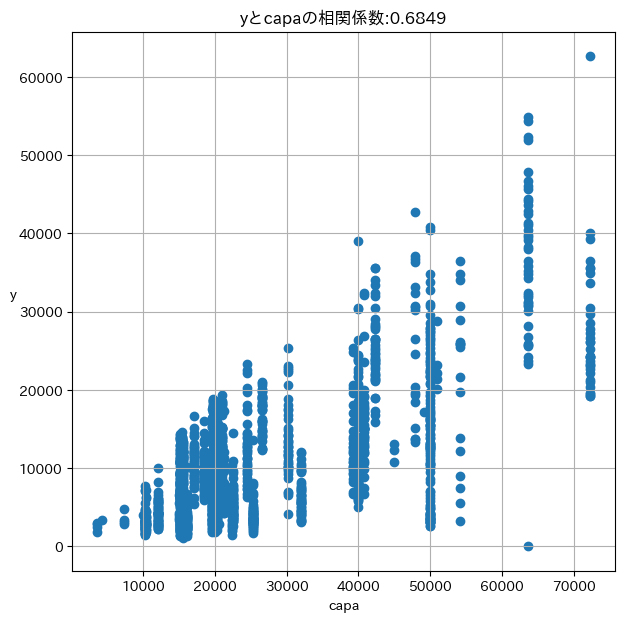

In [11]:
plt.figure(figsize=(7, 7))
plt.scatter(x=full_train['capa'], y=full_train['y'])
plt.grid()
plt.xlabel('capa')
plt.ylabel('y', rotation=0)
plt.title('yとcapaの相関係数:{}'.format(round(full_train.corr(numeric_only=True)['y']['capa'], 4)))
plt.show()

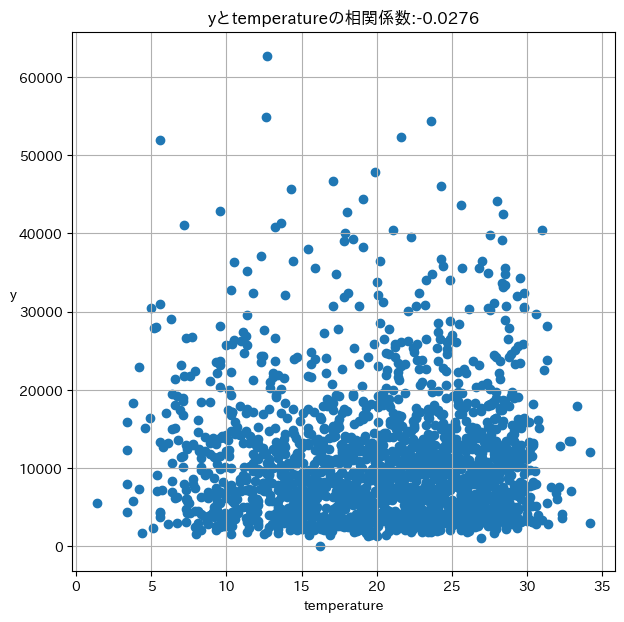

In [12]:
plt.figure(figsize=(7, 7))
plt.scatter(x=full_train['temperature'], y=full_train['y'])
plt.grid()
plt.xlabel('temperature')
plt.ylabel('y', rotation=0)
plt.title('yとtemperatureの相関係数:{}'.format(round(full_train.corr(numeric_only=True)['y']['temperature'], 4)))
plt.show()

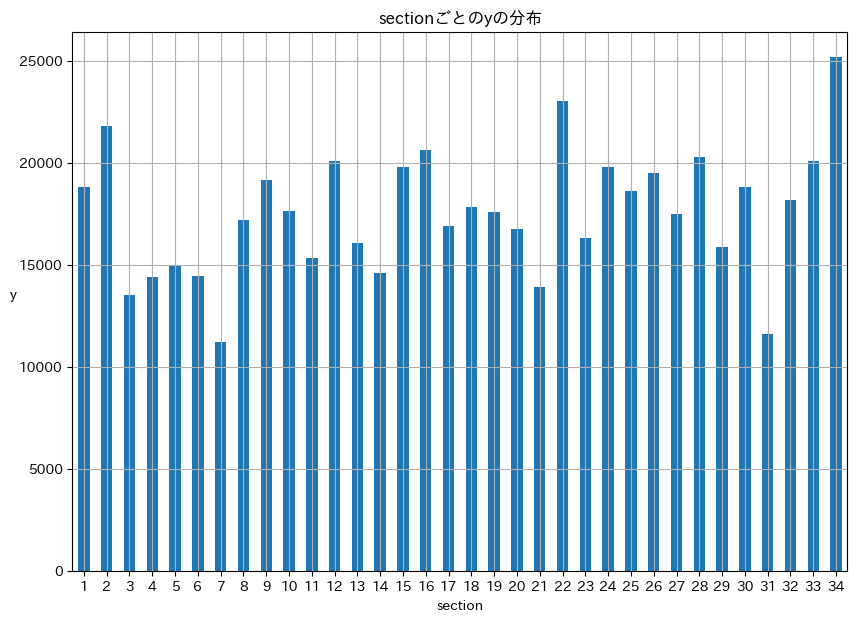

In [13]:

plt.figure(figsize=(10, 7))
full_train[(full_train['stage']=="Ｊ１") & (full_train['year'] == 2012)].groupby('section')['y'].mean().plot.bar()
plt.grid()
plt.xlabel('section')
plt.xticks(rotation=0)
plt.ylabel('y', rotation=0)
plt.title('sectionごとのyの分布')
plt.show()

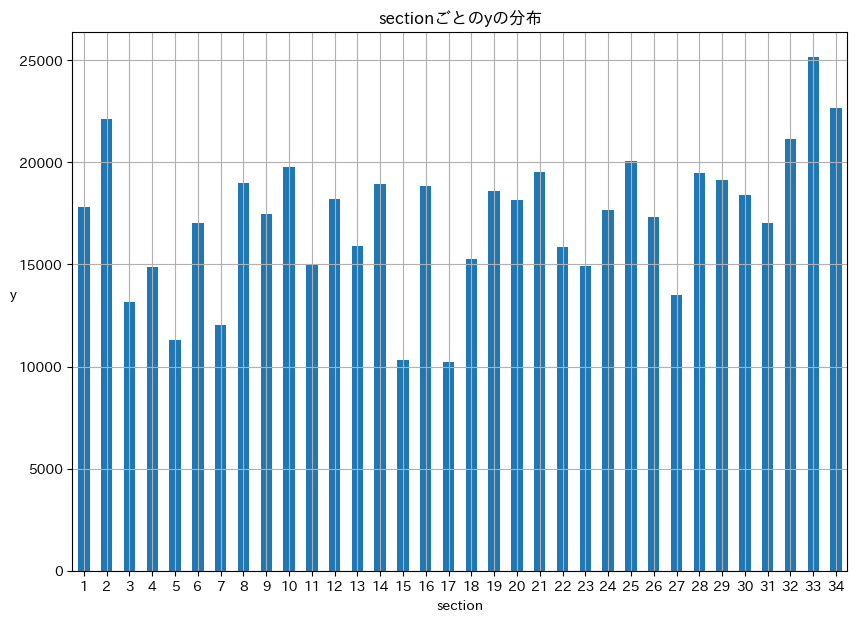

In [14]:
plt.figure(figsize=(10, 7))
full_train[(full_train['stage']=="Ｊ１") & (full_train['year'] == 2013)].groupby('section')['y'].mean().plot.bar()
plt.grid()
plt.xlabel('section')
plt.xticks(rotation=0)
plt.ylabel('y', rotation=0)
plt.title('sectionごとのyの分布')
plt.show()

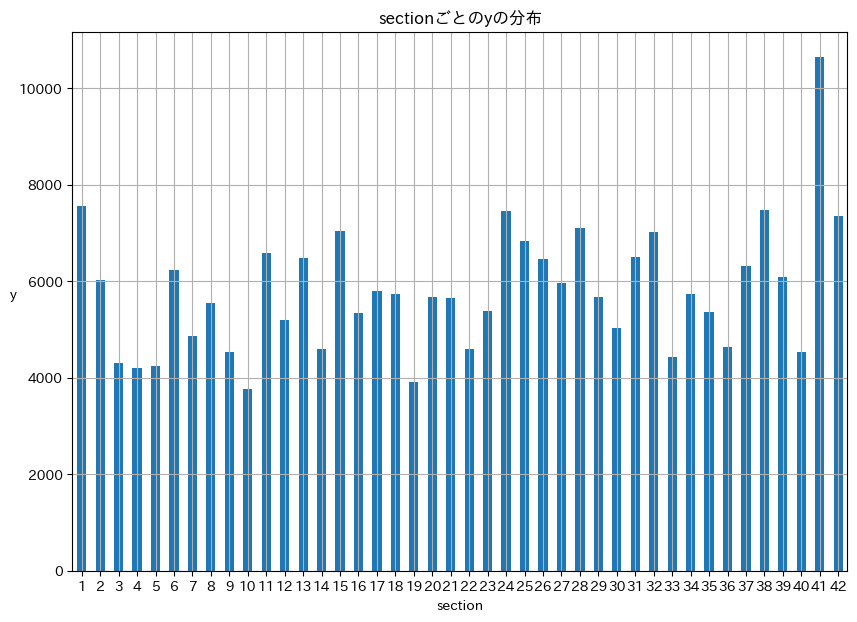

In [15]:
plt.figure(figsize=(10, 7))
full_train[(full_train['stage']=="Ｊ２") & (full_train['year'] == 2012)].groupby('section')['y'].mean().plot.bar()
plt.grid()
plt.xlabel('section')
plt.xticks(rotation=0)
plt.ylabel('y', rotation=0)
plt.title('sectionごとのyの分布')
plt.show()
#print(full_train[(full_train['stage']=="Ｊ１") & (full_train["section"] == 31)])
#print(full_train[(full_train['stage']=="Ｊ１") & (full_train["section"] == 30)])

#print(full_train[(full_train['weekday']=="土") & (full_train['stage']=="Ｊ１")]['y'].describe())
#print(full_train[(full_train['hour']==13) & (full_train['stage']=="Ｊ１")]['y'].describe())


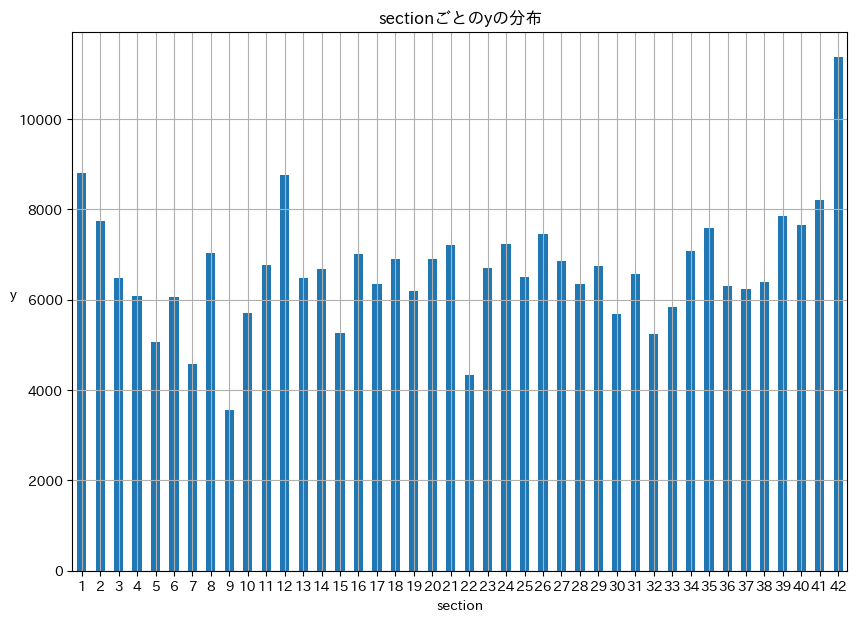

         id      y  year stage   match   gameday   time       home  \
1005  15208   5579  2013    Ｊ２  第７節第１日  04/07(日)  13:04   ザスパクサツ群馬   
1006  15209   3264  2013    Ｊ２  第７節第１日  04/07(日)  13:04       ＦＣ岐阜   
1007  15210   1530  2013    Ｊ２  第７節第１日  04/07(日)  13:03    ガイナーレ鳥取   
1008  15211   6310  2013    Ｊ２  第７節第１日  04/07(日)  13:04   ファジアーノ岡山   
1009  15212   3488  2013    Ｊ２  第７節第１日  04/07(日)  13:04   徳島ヴォルティス   
1010  15213  10010  2013    Ｊ２  第７節第１日  04/07(日)  14:03      ガンバ大阪   
1011  15214   2513  2013    Ｊ２  第７節第１日  04/07(日)  16:03  水戸ホーリーホック   
1012  15215   3086  2013    Ｊ２  第７節第１日  04/07(日)  16:03       横浜ＦＣ   
1013  15216   2315  2013    Ｊ２  第７節第１日  04/07(日)  16:04     カターレ富山   
1014  15217  10559  2013    Ｊ２  第７節第１日  04/07(日)  16:04    ヴィッセル神戸   
1856  15218   1607  2013    Ｊ２  第７節第１日  04/07(日)  16:03  ギラヴァンツ北九州   

             away                    stadium                           tv  \
1005  ジェフユナイテッド千葉                正田醤油スタジアム群馬   スカパー！／スカパー！プレミアムサービス／群馬テレビ   
1006 

<ArrowStringArray>
[       '雨',       '屋内',     '晴一時雨',  '曇一時雨のち晴',        '晴',        '曇',
     '晴時々曇',     '雨のち曇',     '曇時々雨',     '曇時々晴',     '曇のち雨',     '雨のち晴',
     '晴のち曇',  '晴のち曇一時雨',     '曇のち晴',     '晴一時曇',     '曇一時雨', '曇一時雷雨のち曇',
     '晴のち雨',     '雨時々曇',     '晴時々雨',     '晴時々雪',     '雨時々晴',  '曇時々雨のち晴',
  '晴のち曇時々雨',  '雨のち曇時々晴',     '雪のち雨',    '曇のち雷雨',  '曇一時晴一時雨',     '曇一時晴',
  '曇時々晴一時雨',     '曇のち雪',        '雪']
Length: 33, dtype: str

In [16]:
plt.figure(figsize=(10, 7))
full_train[(full_train['stage']=="Ｊ２") & (full_train['year'] == 2013)].groupby('section')['y'].mean().plot.bar()
plt.grid()
plt.xlabel('section')
plt.xticks(rotation=0)
plt.ylabel('y', rotation=0)
plt.title('sectionごとのyの分布')
plt.show()
#print(full_train[(full_train['stage']=="Ｊ１") & (full_train["section"] == 31)])
#print(full_train[(full_train['stage']=="Ｊ１") & (full_train["section"] == 30)])
#print(full_train[(full_train['weekday']=="土") & (full_train['stage']=="Ｊ１")]['y'].describe())
print(full_train[(full_train['section']==7) & (full_train['stage']=="Ｊ２") & (full_train["year"] == 2013)])
print(full_train[(full_train['section']==9) & (full_train['stage']=="Ｊ２") & (full_train["year"] == 2013)])
print(full_train[(full_train['section']==10) & (full_train['stage']=="Ｊ２") & (full_train["year"] == 2013)])
full_train['weather'].unique()


In [17]:
print('section35~40の6section分の試合数 : ', len(full_train.query('35<=section<=40')), '平均観客数 : ', full_train.query('35<=section<=40')['y'].mean())
print('section29~34の6section分の試合数 : ', len(full_train.query('29<=section<=34')), '平均観客数 : ', full_train.query('29<=section<=34')['y'].mean())



section35~40の6section分の試合数 :  132 平均観客数 :  6373.037878787879
section29~34の6section分の試合数 :  240 平均観客数 :  12023.55


In [18]:
full_train.query('35<=section<=40').stage.value_counts()

stage
Ｊ２    132
Name: count, dtype: int64

In [19]:
full_train.query('29<=section<=34').stage.value_counts()

stage
Ｊ２    132
Ｊ１    108
Name: count, dtype: int64

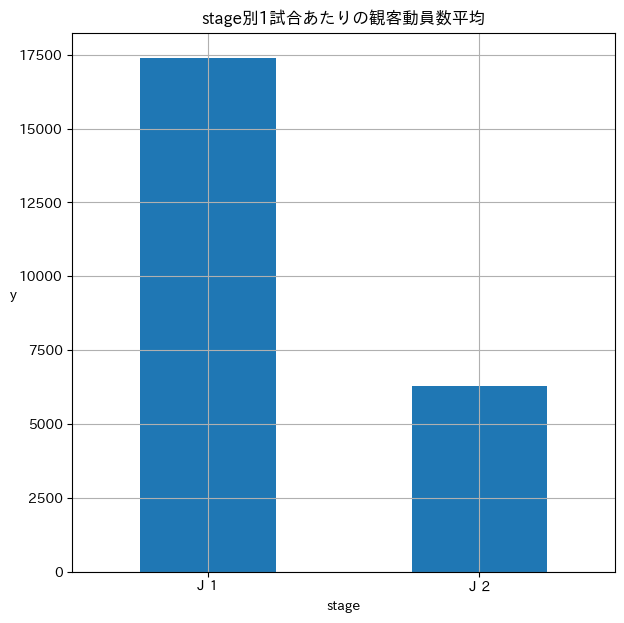

In [20]:
plt.figure(figsize=(7, 7))
full_train.groupby('stage')['y'].mean().plot.bar()
plt.grid()
plt.xticks(rotation=0)
plt.ylabel('y', rotation=0)
plt.title('stage別1試合あたりの観客動員数平均')
plt.show()

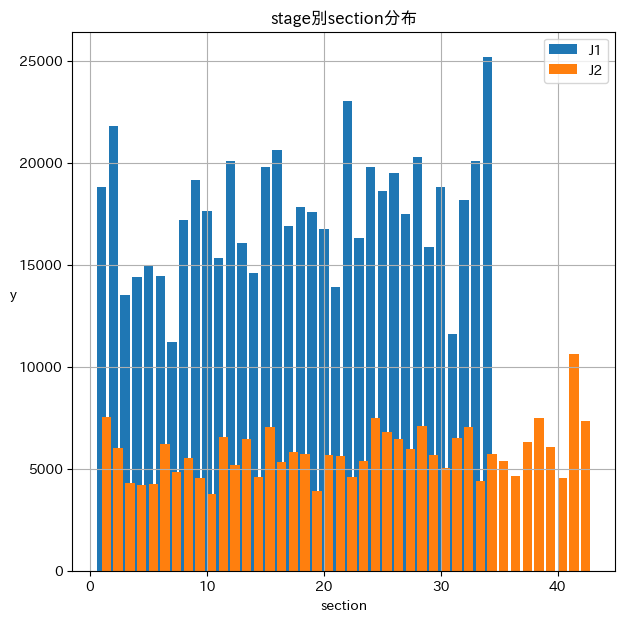

In [21]:
plt.figure(figsize=(7, 7))
J1_group = full_train[(full_train['stage'] == 'Ｊ１') &(full_train['year'] == 2012)].groupby('section')['y'].mean()
J2_group = full_train[(full_train['stage'] == 'Ｊ２') &(full_train['year'] == 2012)].groupby('section')['y'].mean()
plt.bar(J1_group.index, J1_group, label='J1')
plt.bar(J2_group.index, J2_group, label='J2', align='edge')
plt.legend()
plt.grid()
plt.xlabel('section')
plt.ylabel('y', rotation=0)
plt.title('stage別section分布')
plt.show()

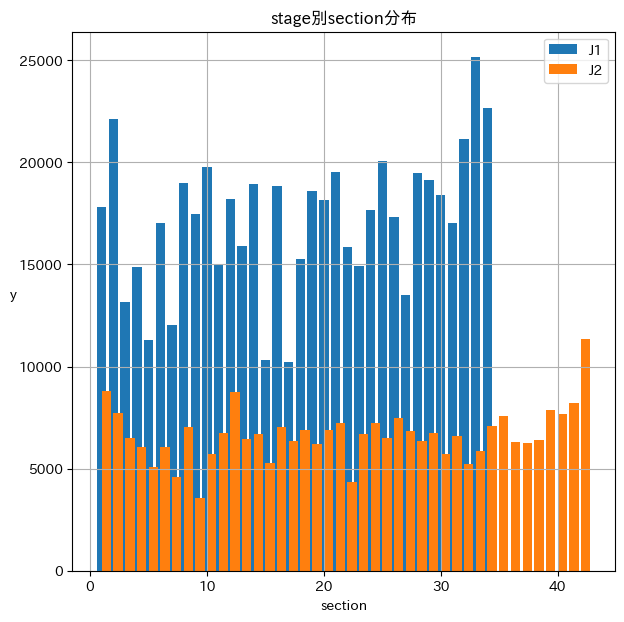

In [22]:
plt.figure(figsize=(7, 7))
J1_group = full_train[(full_train['stage'] == 'Ｊ１') &(full_train['year'] == 2013)].groupby('section')['y'].mean()
J2_group = full_train[(full_train['stage'] == 'Ｊ２') &(full_train['year'] == 2013)].groupby('section')['y'].mean()
plt.bar(J1_group.index, J1_group, label='J1')
plt.bar(J2_group.index, J2_group, label='J2', align='edge')
plt.legend()
plt.grid()
plt.xlabel('section')
plt.ylabel('y', rotation=0)
plt.title('stage別section分布')
plt.show()

In [23]:
full_train[(full_train['stage'] == 'Ｊ１') &(full_train['year'] == 2013) & (full_train['section'] == 16)]

,id,y,year,stage,match,gameday,time,home,away,stadium,tv,capa,weather,temperature,humidity,section,month,weekday,hour,num_tv
797,14971,15191,2013,Ｊ１,第１６節第１日,07/13(土),18:04,清水エスパルス,大分トリニータ,ＩＡＩスタジアム日本平,スカパー！／スカパー！プレミアムサービス,20281,雨,27.4,89,16,7,土,18,2
798,14972,10175,2013,Ｊ１,第１６節第１日,07/13(土),18:34,ヴァンフォーレ甲府,湘南ベルマーレ,山梨中銀スタジアム,スカパー！／スカパー！プレミアムサービス,17000,曇,27.4,57,16,7,土,18,2
799,14973,14318,2013,Ｊ１,第１６節第１日,07/13(土),19:04,ベガルタ仙台,ジュビロ磐田,ユアテックスタジアム仙台,スカパー！／スカパー！プレミアムサービス,19694,曇,21.4,84,16,7,土,19,2
800,14974,25904,2013,Ｊ１,第１６節第１日,07/13(土),19:05,柏レイソル,鹿島アントラーズ,国立競技場,スカパー！／スカパー！プレミアムサービス／ＮＨＫ ＢＳ１,54224,曇,29.7,77,16,7,土,19,3
801,14975,19010,2013,Ｊ１,第１６節第１日,07/13(土),19:03,川崎フロンターレ,浦和レッズ,等々力陸上競技場,スカパー！／スカパー！プレミアムサービス,26530,曇,29.4,73,16,7,土,19,2
802,14976,29722,2013,Ｊ１,第１６節第１日,07/13(土),19:04,横浜Ｆ・マリノス,大宮アルディージャ,日産スタジアム,スカパー！／スカパー！プレミアムサービス,72327,曇,30.6,67,16,7,土,19,2
803,14977,26547,2013,Ｊ１,第１６節第１日,07/13(土),19:03,アルビレックス新潟,ＦＣ東京,デンカビッグスワンスタジアム,スカパー！／スカパー！プレミアムサービス,42300,雨,24.9,80,16,7,土,19,2
804,14978,9237,2013,Ｊ１,第１６節第１日,07/13(土),19:04,名古屋グランパス,サガン鳥栖,名古屋市瑞穂陸上競技場,スカパー！／スカパー！プレミアムサービス,20000,雨,27.9,79,16,7,土,19,2
1827,14979,19244,2013,Ｊ１,第１６節第１日,07/13(土),19:05,サンフレッチェ広島,セレッソ大阪,エディオンスタジアム広島,スカパー！／スカパー！プレミアムサービス,50000,曇のち晴,25.1,93,16,7,土,19,2


In [24]:
use_columns = ['capa', 'section', 'stage', 'month', 'hour', 'num_tv']
y = full_train['y']
train = full_train[use_columns]
test = full_test[use_columns]

#カテゴリ変数のダミー変数化
train = pd.get_dummies(train, drop_first=True)
test = pd.get_dummies(test, drop_first=True)

# 学習データと検証データに分割
X_train, X_valid, y_train, y_valid = train_test_split(train, y, random_state = 82)
print(X_train.shape, X_valid.shape, y_train.shape, y_valid.shape)

(1464, 6) (489, 6) (1464,) (489,)


In [25]:
rfr = RandomForestRegressor(random_state=82)
rfr.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",82
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [26]:
y_pred_train = rfr.predict(X_train)
rmse_train = np.sqrt(MSE(y_train, y_pred_train))

y_pred_valid = rfr.predict(X_valid)
rmse_valid = np.sqrt(MSE(y_valid, y_pred_valid))

print('学習データの予測精度', rmse_train)
print('評価データの予測精度', rmse_valid)

学習データの予測精度 1482.1769583454627
評価データの予測精度 4024.419594977974


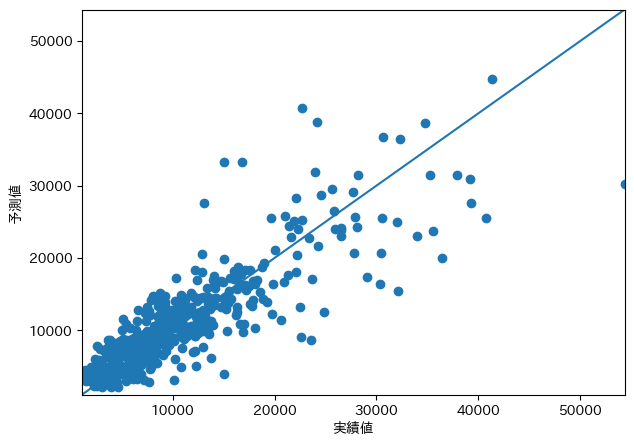

In [27]:
plt.figure(figsize=(7, 5))
plt.scatter(y_valid, y_pred_valid)

min_value = min(y_valid.min(), y_pred_valid.min())
max_value = max(y_valid.max(), y_pred_valid.max())

plt.xlim([min_value,max_value])
plt.ylim([min_value,max_value])
plt.plot([min_value,max_value],[min_value,max_value])

plt.xlabel('実績値')
plt.ylabel('予測値')
plt.show()

In [28]:
predict = rfr.predict(test)

# sample_submitの読み込み
submit = pd.read_csv('sample_submit.csv', header=None)

# 予測結果の適用
submit[1] = predict
submit.to_csv('submission_tutorial.csv', header=None, index=False)

submit.head()

,0,1
0,15822,13901.210000
1,15823,15927.640000
2,15824,31687.270000
3,15825,9147.608000
4,15827,21882.943333


In [29]:
submit

,0,1
0,15822,13901.210000
1,15823,15927.640000
2,15824,31687.270000
3,15825,9147.608000
4,15827,21882.943333
...,...,...
308,16432,6467.320000
309,16433,11629.070000
310,16434,7582.740000
311,16435,8301.080000
